In [705]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [706]:
df = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\processed\nav_history_clean.csv")

In [707]:
df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [708]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [709]:
df["date"] = pd.to_datetime(df["date"])

In [710]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [711]:
fund = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\processed\fund_master_clean.csv")



In [712]:
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [713]:
fund.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB


In [714]:
fund['launch_date'] = pd.to_datetime(fund['launch_date'])  

In [715]:
fund.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   amfi_code           40 non-null     int64         
 1   fund_house          40 non-null     str           
 2   scheme_name         40 non-null     str           
 3   category            40 non-null     str           
 4   sub_category        40 non-null     str           
 5   plan                40 non-null     str           
 6   launch_date         40 non-null     datetime64[us]
 7   benchmark           40 non-null     str           
 8   expense_ratio_pct   40 non-null     float64       
 9   exit_load_pct       40 non-null     float64       
 10  min_sip_amount      40 non-null     int64         
 11  min_lumpsum_amount  40 non-null     int64         
 12  fund_manager        40 non-null     str           
 13  risk_category       40 non-null     str           
 14  sebi_ca

In [716]:
df = df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [717]:
# Filter data for 2022–2026
df = df[
    (df["date"] >= "2022-01-01") &
    (df["date"] <= "2026-12-31")
]

# Sort data
df = df.sort_values(["scheme_name", "date"])

# Create interactive line chart
fig = px.line(
    df,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (₹)",
        "scheme_name": "Scheme"
    },
    template="plotly_white"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    layer="below",
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-10-31",
    fillcolor="red",
    opacity=0.12,
    layer="below",
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

# Improve appearance
fig.update_layout(
    title_x=0.5,
    height=750,
    width=1400,
    hovermode="x unified",
    legend_title="Mutual Fund Scheme",
    font=dict(size=13),
    xaxis_title="Date",
    yaxis_title="NAV (₹)"
)

# Slightly thicker lines
fig.update_traces(line=dict(width=1.5))

# Display chart
fig.show()

In [718]:
fig.write_image(
    "../reports/charts/nav_trend_2022_2026.png",
    width=1600,
    height=900,
    scale=2
)

## NAV Trend Analysis (2022–2026)

This visualization shows the daily Net Asset Value (NAV) trend for all 40 mutual fund schemes from 2022 to 2026. The chart highlights the strong market rally during 2023 (bull run) and the market correction observed in 2024, providing insights into long-term fund performance and market volatility.

**Key Insight:** Overall NAV values exhibit an upward long-term trend despite temporary declines during the 2024 market correction.

**Chart Type:** Plotly Line Chart

In [719]:
aum=pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\processed\aum_by_fund_house_clean.csv")

In [720]:
aum.head(5)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199
1,2022-09-30,Aditya Birla Sun Life MF,2.85,285000,199
2,2023-03-31,Aditya Birla Sun Life MF,2.75,275000,199
3,2023-09-30,Aditya Birla Sun Life MF,3.08,308000,199
4,2024-03-31,Aditya Birla Sun Life MF,3.40,340000,199


In [721]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [722]:
aum["date"] = pd.to_datetime(aum["date"])

In [723]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            90 non-null     datetime64[us]
 1   fund_house      90 non-null     str           
 2   aum_lakh_crore  90 non-null     float64       
 3   aum_crore       90 non-null     int64         
 4   num_schemes     90 non-null     int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 3.6 KB


In [724]:
aum["year"] = aum["date"].dt.year
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199,2022
1,2022-09-30,Aditya Birla Sun Life MF,2.85,285000,199,2022
2,2023-03-31,Aditya Birla Sun Life MF,2.75,275000,199,2023
3,2023-09-30,Aditya Birla Sun Life MF,3.08,308000,199,2023
4,2024-03-31,Aditya Birla Sun Life MF,3.40,340000,199,2024


In [725]:
aum = aum[aum["year"].between(2022, 2025)]

In [726]:
aum[aum["fund_house"].str.contains("SBI", case=False)]

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
72,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
73,2022-09-30,SBI Mutual Fund,6.30,630000,186,2022
74,2023-03-31,SBI Mutual Fund,7.17,717000,186,2023
75,2023-09-30,SBI Mutual Fund,8.45,845000,186,2023
76,2024-03-31,SBI Mutual Fund,10.00,1000000,186,2024
77,2024-09-30,SBI Mutual Fund,10.80,1080000,186,2024
78,2024-12-31,SBI Mutual Fund,11.14,1114000,186,2024
79,2025-03-31,SBI Mutual Fund,12.50,1250000,186,2025
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025


In [727]:
# Keep the latest AUM record for each fund house and year
aum_latest = (
    aum.sort_values("date")
       .groupby(["fund_house", "year"], as_index=False)
       .last()
)

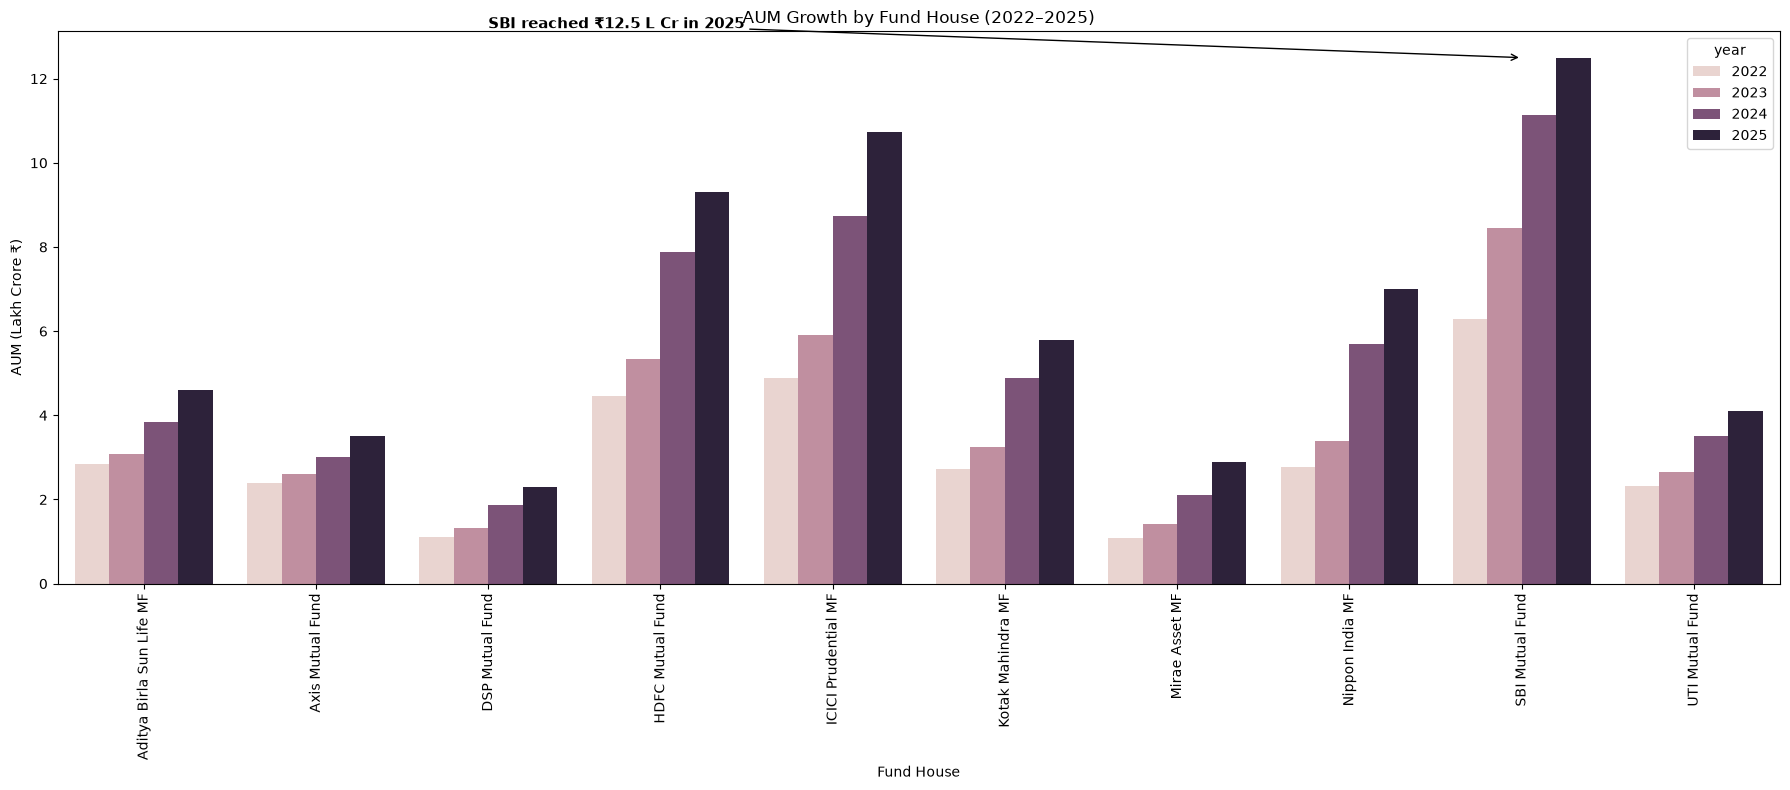

In [728]:
plt.figure(figsize=(18,8))

sns.barplot(
    data=aum_latest,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=90)
plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore ₹)")

plt.annotate(
    "SBI reached ₹12.5 L Cr in 2025",
    xy=("SBI Mutual Fund", 12.5),
    xytext=(2, 13.2),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("../reports/charts/aum_growth_bar_chart.png", dpi=300)
plt.show()

### EDA Finding

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) from 2022 to 2025, reaching approximately **₹12.5 lakh crore** in 2025. Most fund houses exhibited steady AUM growth during the analysis period, indicating continued expansion of the mutual fund industry.

**Supporting Chart:** AUM Growth by Fund House (2022–2025)

## SIP Inflow Trend Analysis (January 2022 – December 2025)

This analysis examines the monthly Systematic Investment Plan (SIP) inflows from January 2022 to December 2025. The objective is to understand the growth in retail investor participation and identify major milestones in SIP contributions over the analysis period.

The visualization also highlights the record monthly SIP inflow of **₹31,002 crore** achieved in **December 2025**, reflecting the increasing adoption of systematic investing.

**Visualization:** Plotly Line Chart

In [729]:
sip = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\raw\04_monthly_sip_inflows - Copy.csv")

In [730]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [731]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [732]:
# Filter Jan 2022 - Dec 2025
sip = sip[
    (sip["month"] >= "2022-01-01") &
    (sip["month"] <= "2025-12-31")
].copy()

# Ensure datetime format
sip["month"] = pd.to_datetime(sip["month"])

# Find the all-time high
peak = sip.loc[sip["sip_inflow_crore"].idxmax()]

# Convert peak month to string
peak_month = peak["month"].strftime("%Y-%m-%d")

# Create Plotly line chart
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    },
    template="plotly_white"
)

# Format line
fig.update_traces(
    line=dict(width=3, color="royalblue"),
    marker=dict(size=6)
)

# Highlight peak
fig.add_scatter(
    x=[peak["month"]],
    y=[peak["sip_inflow_crore"]],
    mode="markers",
    marker=dict(
        size=14,
        color="red",
        symbol="star"
    ),
    name="All-Time High"
)

# Annotation
fig.add_annotation(
    x=peak_month,
    y=peak["sip_inflow_crore"],
    text=f"₹{peak['sip_inflow_crore']:,} Cr<br>All-Time High",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.2,
    arrowwidth=2,
    ax=-80,
    ay=-70,
    bgcolor="yellow",
    bordercolor="black"
)

# Vertical dashed line (works with PNG export)
fig.add_shape(
    type="line",
    x0=peak_month,
    x1=peak_month,
    y0=0,
    y1=sip["sip_inflow_crore"].max(),
    line=dict(color="red", dash="dash", width=2)
)

# Layout
fig.update_layout(
    title_x=0.5,
    height=600,
    width=1200,
    hovermode="x unified",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    font=dict(size=13)
)

# Show chart
fig.show()

In [733]:
fig.write_html(
    "../reports/charts/sip_inflow_trend_2022_2025.html"
)

### EDA Finding

Monthly SIP inflows increased steadily between January 2022 and December 2025, demonstrating consistent growth in retail investor participation. The highest monthly SIP inflow of **₹31,002 crore** was recorded in **December 2025**, indicating strong investor confidence and sustained expansion of the mutual fund industry.

**Supporting Chart:** SIP Inflow Trend Analysis (Plotly Line Chart)

## Category-wise Monthly Net Inflow Heatmap

This heatmap visualizes the monthly net inflows across different mutual fund categories from 2022 to 2025. The color intensity represents the magnitude of net inflows, enabling easy identification of high- and low-performing fund categories over time.

**Objective:** Analyze monthly investment patterns across fund categories and identify periods of strong or weak investor inflows.

**Visualization:** Seaborn Heatmap

In [734]:
cat=pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\raw\05_category_inflows - Copy.csv")

In [735]:
cat.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [736]:
cat.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB


In [737]:
cat["month"] = pd.to_datetime(cat["month"], format="%Y-%m")

In [738]:
cat.isnull().sum()

month               0
category            0
net_inflow_crore    0
dtype: int64

In [739]:
cat.duplicated().sum()

np.int64(0)

In [740]:
cat.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   month             144 non-null    datetime64[us]
 1   category          144 non-null    str           
 2   net_inflow_crore  144 non-null    float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 3.5 KB


In [741]:
cat = cat.sort_values("month").reset_index(drop=True)

In [742]:
cat.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Hybrid,2955.0
2,2024-04-01,Gilt,784.0
3,2024-04-01,Short Duration,4400.0
4,2024-04-01,Sectoral/Thematic,8052.0


In [743]:
cat["category"].unique()

<StringArray>
[        'Large Cap',            'Hybrid',              'Gilt',
    'Short Duration', 'Sectoral/Thematic',      'Value/Contra',
            'Liquid',   'Large & Mid Cap',         'Flexi Cap',
         'Small Cap',           'Mid Cap',              'ELSS']
Length: 12, dtype: str

In [744]:
cat["month_label"] = cat["month"].dt.strftime("%b-%y")

In [745]:
cat["month_label"].head()

0    Apr-24
1    Apr-24
2    Apr-24
3    Apr-24
4    Apr-24
Name: month_label, dtype: str

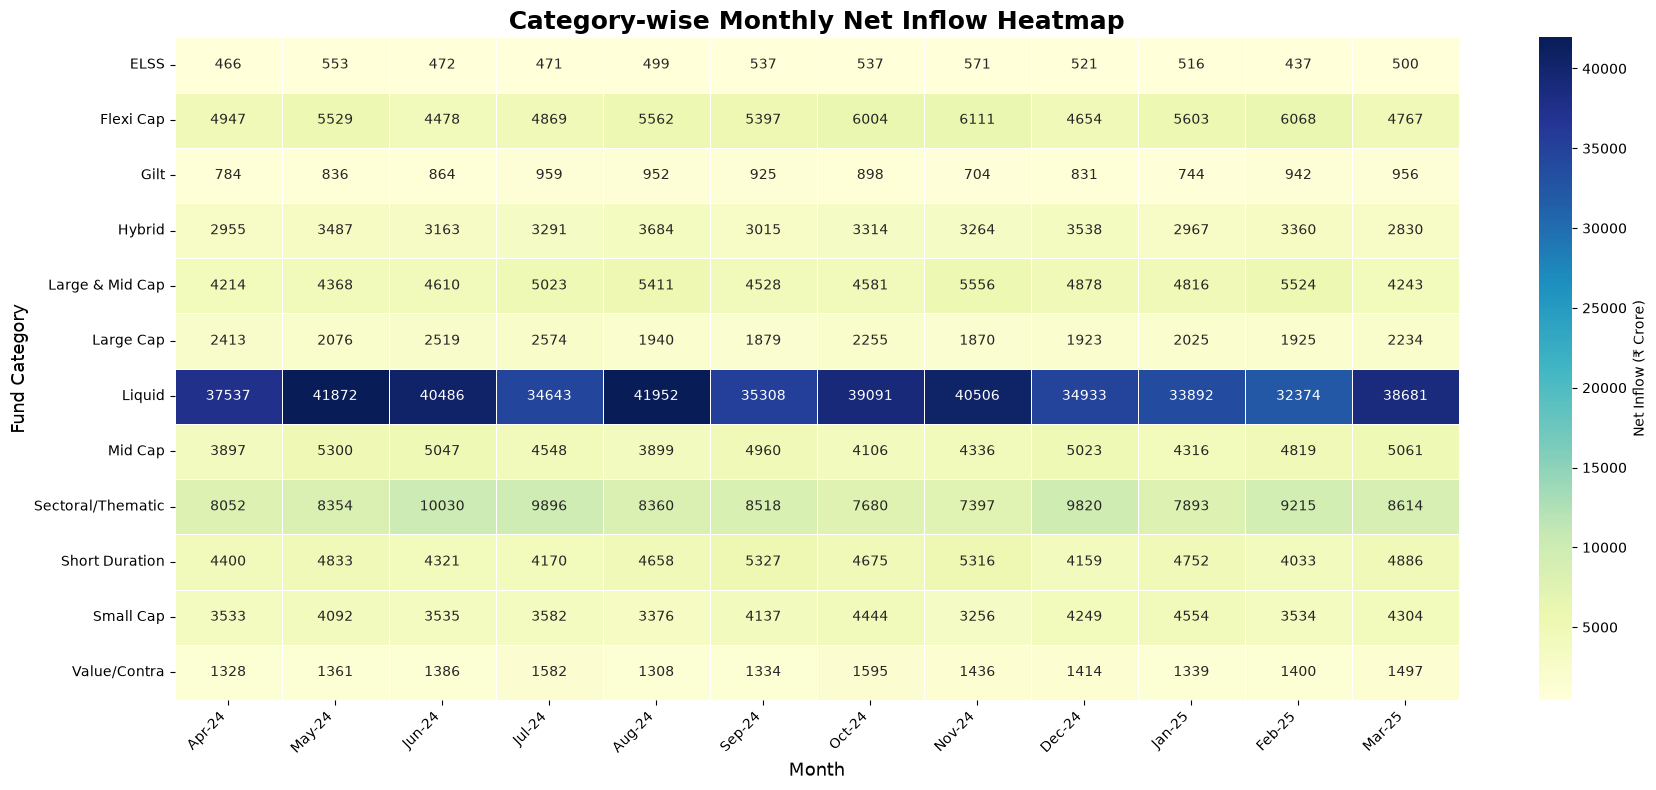

In [746]:
# pivot table
heatmap_data = cat.pivot(
    index="category",
    columns="month_label",
    values="net_inflow_crore"
)

# Arrange months chronologically
month_order = (
    cat[["month", "month_label"]]
    .drop_duplicates()
    .sort_values("month")["month_label"]
)

heatmap_data = heatmap_data[month_order]

# -----------------------------
# Plot Heatmap
# -----------------------------

plt.figure(figsize=(18, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title(
    "Category-wise Monthly Net Inflow Heatmap",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month", fontsize=13)
plt.ylabel("Fund Category", fontsize=13)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "../reports/charts/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### EDA Finding

The heatmap reveals noticeable variations in monthly net inflows across mutual fund categories. Equity-oriented categories generally record stronger inflows than other categories, while several categories exhibit seasonal fluctuations in investor activity throughout the analysis period.

**Supporting Chart:** Category-wise Monthly Net Inflow Heatmap (Seaborn Heatmap)

## Investor Age Group Distribution

This pie chart illustrates the distribution of investors across different age groups. It helps identify which age segment contributes the largest share of mutual fund investors and provides insights into the demographic profile of the investor base.

**Objective:** Analyze the age-wise distribution of investors to understand the dominant investor segments in the mutual fund market.

**Visualization:** Matplotlib Pie Chart

In [747]:
investor=pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\raw\08_investor_transactions - Copy.csv")

In [748]:
investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [749]:
investor.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


In [750]:
investor["transaction_date"] = pd.to_datetime(investor["transaction_date"])

In [751]:
investor.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   investor_id         32778 non-null  str           
 1   transaction_date    32778 non-null  datetime64[us]
 2   amfi_code           32778 non-null  int64         
 3   transaction_type    32778 non-null  str           
 4   amount_inr          32778 non-null  int64         
 5   state               32778 non-null  str           
 6   city                32778 non-null  str           
 7   city_tier           32778 non-null  str           
 8   age_group           32778 non-null  str           
 9   gender              32778 non-null  str           
 10  annual_income_lakh  32778 non-null  float64       
 11  payment_mode        32778 non-null  str           
 12  kyc_status          32778 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(9)
memory

In [752]:
investor.duplicated().sum()

np.int64(0)

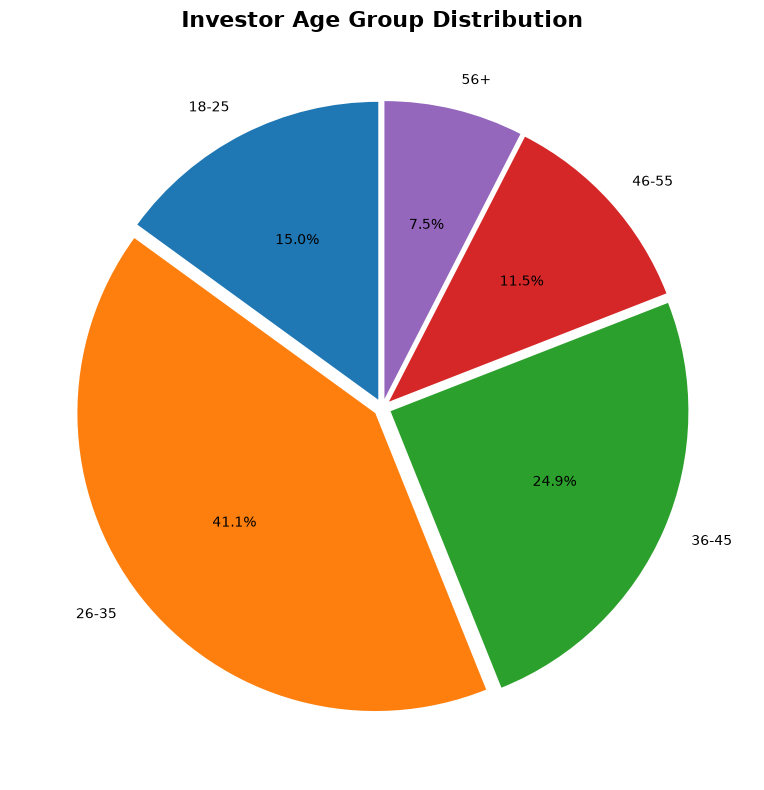

In [753]:
# Count investors by age group
age_counts = (
    investor["age_group"]
    .value_counts()
    .reindex(["18-25", "26-35", "36-45", "46-55", "56+"])
)

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03]*len(age_counts)
)

plt.title("Investor Age Group Distribution", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig(
    "../reports/charts/investor_age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### EDA Finding

The investor base is concentrated within the younger and middle-aged groups, indicating that these segments contribute the largest share of mutual fund participation. Older age groups account for a comparatively smaller proportion of investors.

**Supporting Chart:** Investor Age Group Distribution (Matplotlib Pie Chart)

## SIP Amount Distribution by Age Group

This box plot compares the distribution of SIP investment amounts across different age groups. It highlights the median investment amount, spread, and potential outliers for each age segment, enabling comparison of investment behavior across age groups.

**Objective:** Analyze how SIP investment amounts vary among different investor age groups.

**Visualization:** Seaborn Box Plot

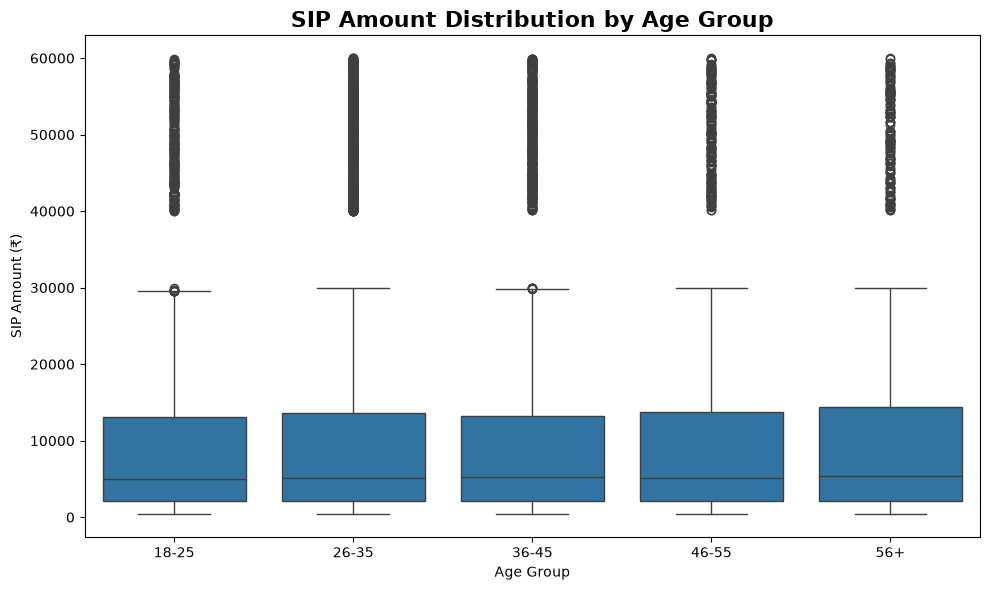

In [754]:
#  SIP transactions
sip = investor[investor["transaction_type"] == "SIP"]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip,
    x="age_group",
    y="amount_inr",
    order=["18-25", "26-35", "36-45", "46-55", "56+"]
)

plt.title("SIP Amount Distribution by Age Group", fontsize=16, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.tight_layout()
plt.savefig(
    "../reports/charts/sip_amount_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### EDA Finding

The distribution of SIP investment amounts varies across age groups, with differences in median values and variability. Some age groups also exhibit a wider spread and higher-value outliers, indicating diverse investment capacities and preferences.

**Supporting Chart:** SIP Amount Distribution by Age Group (Seaborn Box Plot)

## Gender Distribution of Investors

This pie chart illustrates the proportion of investors by gender. It provides an overview of the gender composition of the investor base and helps assess the level of participation across different gender groups.

**Objective:** Analyze the gender distribution of mutual fund investors.

**Visualization:** Matplotlib Pie Chart

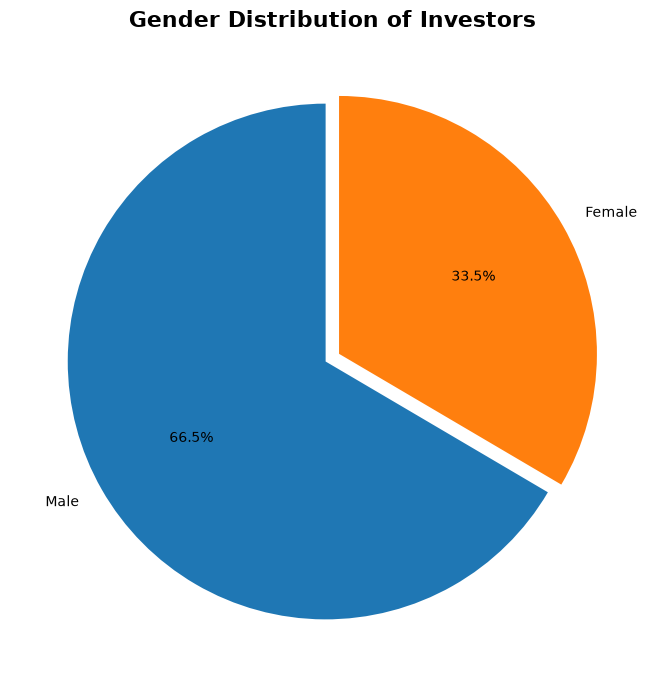

In [755]:
gender_counts = investor["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03]*len(gender_counts)
)

plt.title("Gender Distribution of Investors", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig(
    "../reports/charts/gender_distribution_of_investors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### EDA Finding

The gender distribution indicates participation from multiple gender groups in mutual fund investments. The chart highlights the proportion contributed by each group, providing insights into the overall diversity of the investor base.

**Supporting Chart:** Gender Distribution of Investors (Matplotlib Pie Chart)

## Geographic Distribution of SIP Investments by State

This horizontal bar chart shows the total SIP investment amount contributed by each state. It helps identify the states with the highest and lowest SIP contributions, providing insights into the geographic distribution of mutual fund investments.

**Objective:** Analyze state-wise SIP investment patterns and identify regions with higher investor participation.

**Visualization:** Matplotlib Horizontal Bar Chart

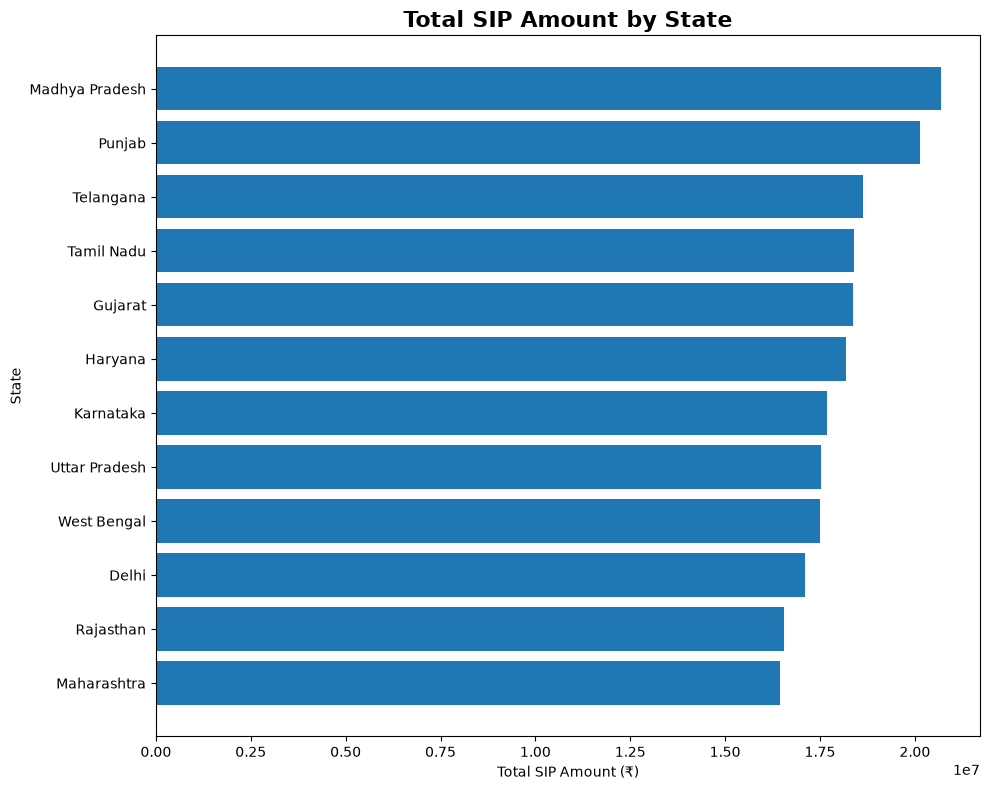

In [756]:
# Filter only SIP transactions
sip = investor[investor["transaction_type"] == "SIP"]

# Total SIP amount by state
state_sip = (
    sip.groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,8))

plt.barh(
    state_sip.index,
    state_sip.values
)

plt.title("Total SIP Amount by State", fontsize=16, fontweight="bold")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.savefig(
    "../reports/charts/state_wise_sip_amount.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### EDA Finding

SIP investment amounts vary across states, with some states contributing significantly higher total investments than others. This geographic variation highlights differences in investor participation and mutual fund adoption across regions.

**Supporting Chart:** Total SIP Amount by State (Matplotlib Horizontal Bar Chart)

## T30 vs B30 City Tier Distribution

This pie chart compares the distribution of investors across **T30 (Top 30)** and **B30 (Beyond Top 30)** city tiers. It provides insights into the geographic concentration of mutual fund investors and the relative participation of metropolitan and non-metropolitan regions.

**Objective:** Analyze investor distribution across T30 and B30 city tiers to understand regional participation in mutual fund investments.

**Visualization:** Matplotlib Pie Chart

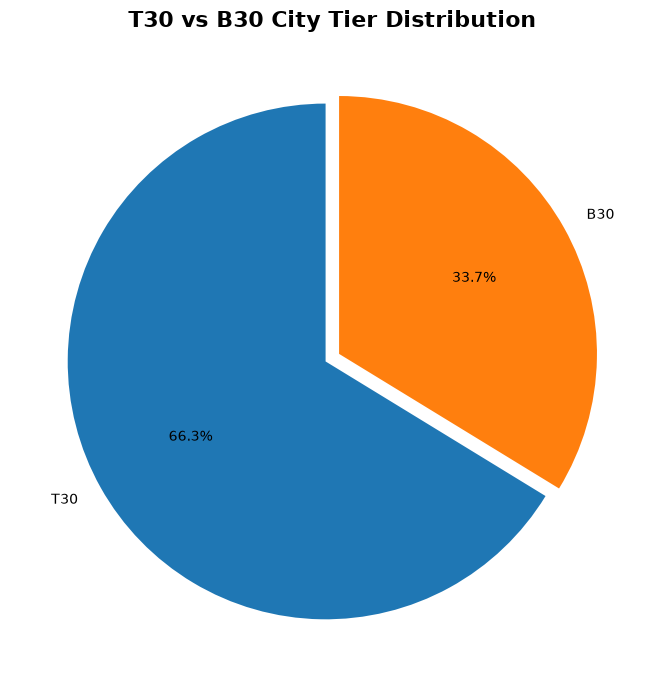

In [757]:
city_counts = investor["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03]*len(city_counts)
)

plt.title("T30 vs B30 City Tier Distribution", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig(
    "../reports/charts/t30_vs_b30_city_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### EDA Finding

The investor base is distributed across both T30 and B30 city tiers, reflecting mutual fund participation in metropolitan as well as non-metropolitan regions. The chart illustrates

## Industry Folio Count Growth (2022–2025)

This line chart illustrates the growth in the total number of mutual fund folios from 2022 to 2025. It highlights the increase in investor accounts over time and marks important milestones, including the point where total folios crossed **20 crore**.

**Objective:** Analyze the growth trend of mutual fund folios and identify significant milestones in investor participation.

**Visualization:** Plotly Line Chart

In [758]:
folio=pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\raw\06_industry_folio_count - Copy.csv")

In [759]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [760]:
folio.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     str    
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.1 KB


In [761]:
folio.duplicated().sum()

np.int64(0)

In [762]:
#month column to datetime
folio["month"] = pd.to_datetime(folio["month"], format="%Y-%m")

#line chart
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Industry Folio Count Growth (2022–2025)",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    },
    template="plotly_white"
)

# Start point
fig.add_trace(
    go.Scatter(
        x=[folio.iloc[0]["month"]],
        y=[folio.iloc[0]["total_folios_crore"]],
        mode="markers+text",
        text=[f"Start<br>{folio.iloc[0]['total_folios_crore']:.2f} Cr"],
        textposition="top center",
        marker=dict(size=10, color="green"),
        showlegend=False
    )
)

# End point
fig.add_trace(
    go.Scatter(
        x=[folio.iloc[-1]["month"]],
        y=[folio.iloc[-1]["total_folios_crore"]],
        mode="markers+text",
        text=[f"Latest<br>{folio.iloc[-1]['total_folios_crore']:.2f} Cr"],
        textposition="top center",
        marker=dict(size=10, color="red"),
        showlegend=False
    )
)

# Milestone
milestone = folio[folio["total_folios_crore"] >= 20]

if not milestone.empty:
    first = milestone.iloc[0]

    fig.add_trace(
        go.Scatter(
            x=[first["month"]],
            y=[first["total_folios_crore"]],
            mode="markers+text",
            text=["20 Cr Crossed"],
            textposition="bottom center",
            marker=dict(size=12, color="orange", symbol="star"),
            showlegend=False
        )
    )

fig.update_layout(
    title_x=0.5,
    hovermode="x unified",
    height=600,
    width=1200
)


fig.show()

In [764]:
fig.write_html("../reports/charts/folio_count_growth_2022_2025.html")

### EDA Finding

The mutual fund industry experienced consistent growth in total folio count from 2022 to 2025, indicating increasing investor participation. The industry crossed the **20 crore folio** milestone during the analysis period, reflecting strong expansion in retail investments and growing awareness of mutual fund products.

**Supporting Chart:** Industry Folio Count Growth (2022–2025) – Plotly Line Chart

## NAV Return Correlation Matrix (10 Selected Funds)

This heatmap displays the pairwise correlation of daily NAV returns for ten selected mutual fund schemes. Correlation analysis helps identify how similarly different funds move over time and provides insights into diversification opportunities.

**Objective:** Measure the relationship between the daily returns of selected mutual fund schemes and identify highly correlated or diversified funds.

**Visualization:** Seaborn Correlation Heatmap

In [ ]:
df["amfi_code"].unique()

array([101206, 101208, 101207, 119093, 119092, 119094, 119095, 149323,
       149324, 149322, 125498, 100033, 100025, 125497, 100016, 120504,
       120503, 120507, 120505, 120506, 120841, 120842, 120843, 120844,
       148568, 148567, 148569, 118635, 118636, 118633, 118632, 118634,
       119552, 119551, 119120, 119599, 119598, 102887, 102886, 102885])

In [ ]:
top10 = [
    101206, 101208, 101207,
    119093, 119092, 119094,
    119095, 149323, 149324,
    149322
]

In [ ]:
# Filter selected funds
nav10 = df[df["amfi_code"].isin(top10)].copy()

In [ ]:
nav10.head()

,amfi_code,date,nav,scheme_name
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth


In [ ]:
nav10.info()

<class 'pandas.DataFrame'>
Index: 11500 entries, 3450 to 43699
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   amfi_code    11500 non-null  int64         
 1   date         11500 non-null  datetime64[us]
 2   nav          11500 non-null  float64       
 3   scheme_name  11500 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 449.2 KB


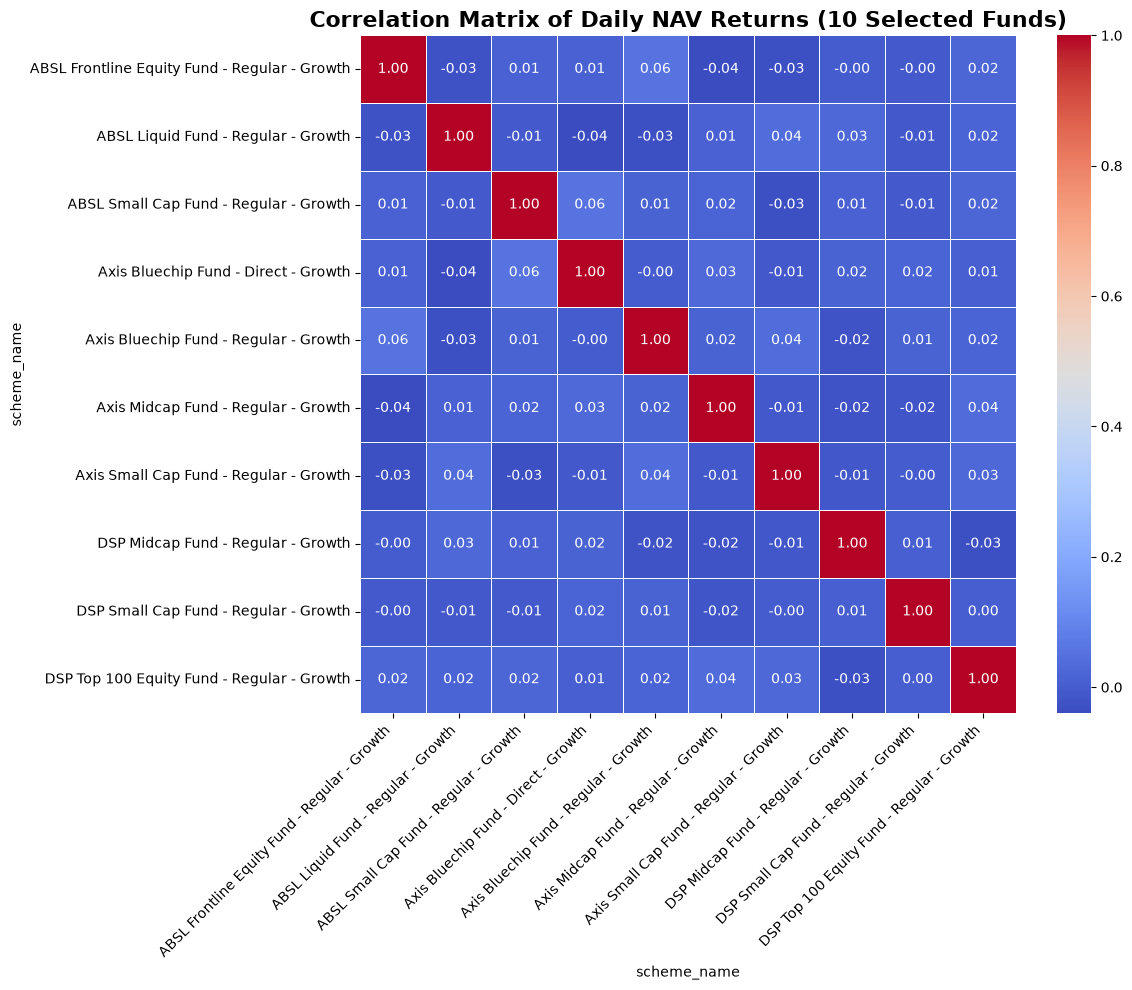

In [765]:
# Sort by scheme and date
nav10 = nav10.sort_values(["scheme_name", "date"])

# Calculate daily returns
nav10["daily_return"] = (
    nav10.groupby("scheme_name")["nav"]
    .pct_change()
)

# Create pivot table
returns = nav10.pivot(
    index="date",
    columns="scheme_name",
    values="daily_return"
)

# Compute correlation matrix
corr_matrix = returns.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Daily NAV Returns (10 Selected Funds)",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "../reports/charts/nav_return_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### EDA Finding

The correlation matrix shows that several equity mutual funds exhibit strong positive correlations in their daily NAV returns, indicating similar responses to market movements. Funds with lower correlation values offer better diversification benefits, helping investors reduce overall portfolio risk.

**Supporting Chart:** NAV Return Correlation Matrix (10 Selected Funds) – Seaborn Heatmap

## Sector Allocation Across All Equity Funds

This donut chart illustrates the aggregate portfolio allocation across different market sectors by combining the holdings of all equity mutual funds. It highlights the sectors that receive the largest share of investments and provides an overview of portfolio diversification.

**Objective:** Analyze the overall sector allocation of equity mutual funds and identify the sectors with the highest portfolio exposure.

**Visualization:** Matplotlib Donut Chart

In [ ]:
portfolio = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\raw\09_portfolio_holdings.csv")

In [ ]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [ ]:
portfolio.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.3 KB


In [ ]:
portfolio["portfolio_date"] = pd.to_datetime(portfolio["portfolio_date"])

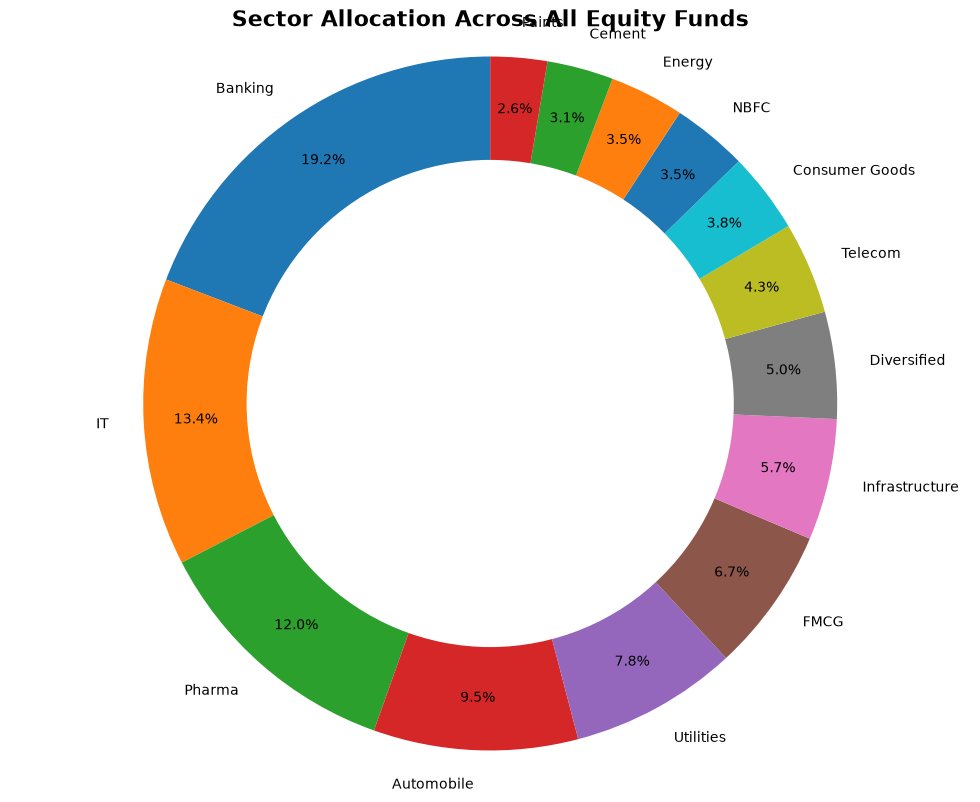

In [766]:
# Aggregate sector weights across all funds
sector_weights = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

# Create figure
plt.figure(figsize=(10, 8))

# Donut chart
plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.85
)

# Add center circle
centre_circle = plt.Circle((0, 0), 0.70, color="white")
plt.gca().add_artist(centre_circle)

# Equal aspect ratio
plt.axis("equal")

plt.title(
    "Sector Allocation Across All Equity Funds",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "../reports/charts/sector_allocation_donut_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### EDA Finding

The aggregated portfolio allocation shows that investments are concentrated in a few key sectors, while the remaining sectors receive comparatively smaller allocations. This distribution reflects the sector preferences of equity mutual funds and highlights the overall diversification strategy adopted across fund portfolios.

**Supporting Chart:** Sector Allocation Across All Equity Funds – Matplotlib Donut Chart

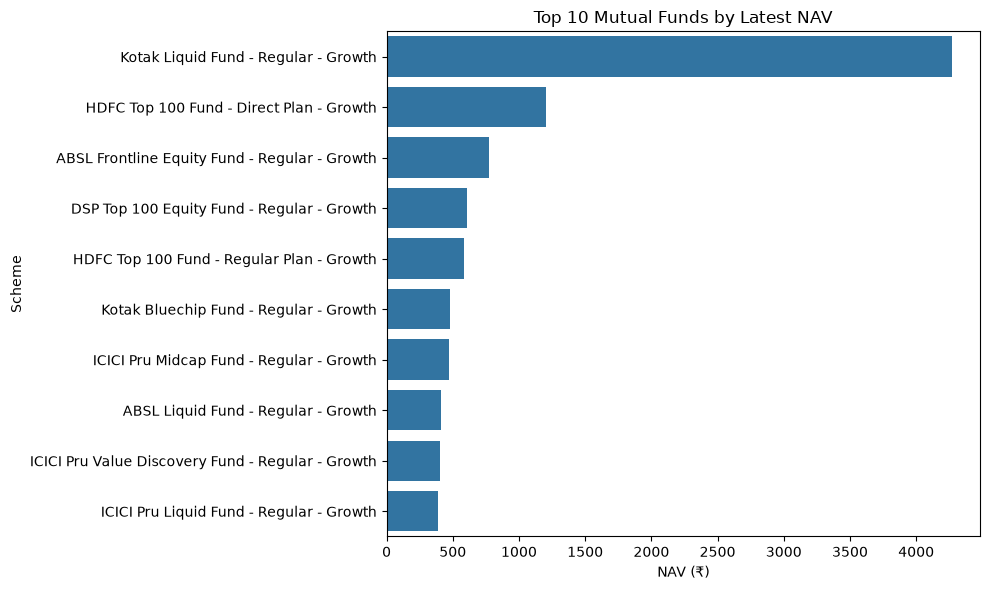

In [767]:
latest_nav = (
    df.sort_values("date")
       .groupby("scheme_name")
       .tail(1)
       .sort_values("nav", ascending=False)
       .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=latest_nav,
    x="nav",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by Latest NAV")
plt.xlabel("NAV (₹)")
plt.ylabel("Scheme")

plt.tight_layout()
plt.savefig("../reports/charts/top10_latest_nav.png", dpi=300)
plt.show()

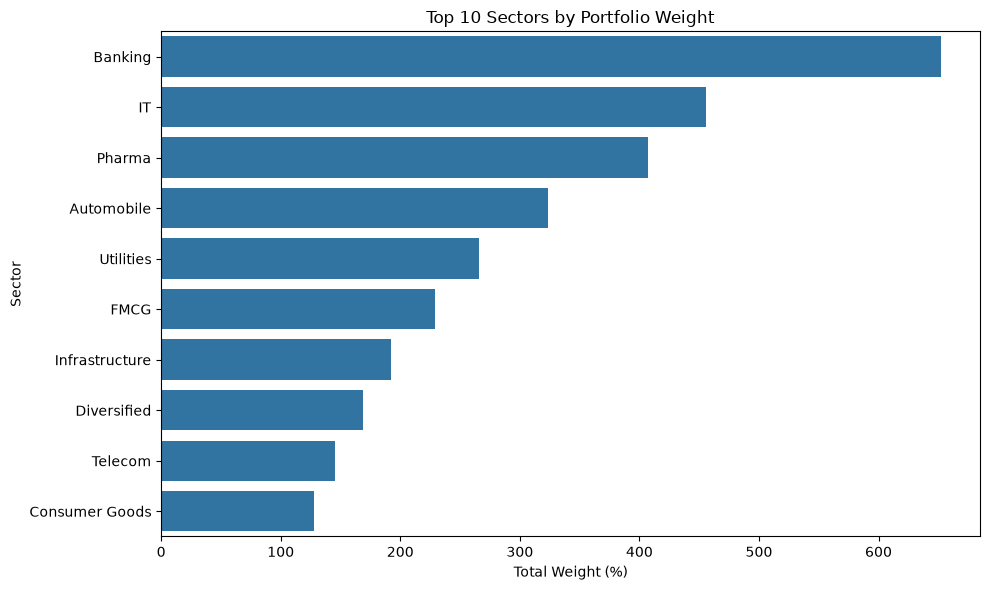

In [768]:
top_sector = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_sector.values,
    y=top_sector.index
)

plt.title("Top 10 Sectors by Portfolio Weight")
plt.xlabel("Total Weight (%)")
plt.ylabel("Sector")

plt.tight_layout()
plt.savefig("../reports/charts/top10_sector_weight.png", dpi=300)
plt.show()

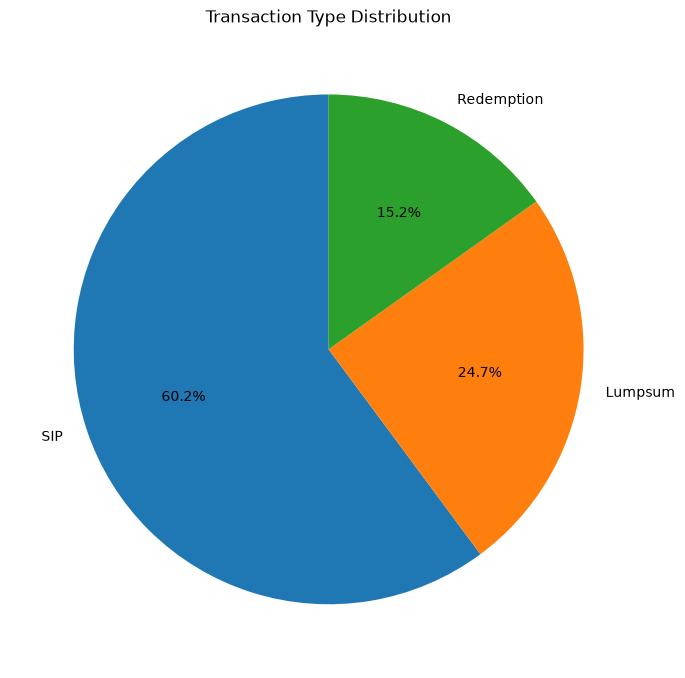

In [769]:
plt.figure(figsize=(7,7))

investor["transaction_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Transaction Type Distribution")

plt.tight_layout()
plt.savefig("../reports/charts/transaction_type_distribution.png", dpi=300)
plt.show()